# Backtest Visualization — Submission 24058
Parses the IMC web backtester log and visualizes trades, PnL, and position over time.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.formatter.useoffset": False,
})

# --- Load log ---
with open("24058.log") as f:
    data = json.load(f)

activities = pd.read_csv(StringIO(data["activitiesLog"]), sep=";")
activities["spread"] = activities["ask_price_1"] - activities["bid_price_1"]

trades = pd.DataFrame(data["tradeHistory"])
trades["side"] = np.where(trades["buyer"] == "SUBMISSION", "BUY", "SELL")
trades["signed_qty"] = np.where(trades["side"] == "BUY", trades["quantity"], -trades["quantity"])

products = sorted(activities["product"].unique())
print(f"Products: {products}")
print(f"Total own trades: {len(trades)}")
print(f"Days: {sorted(activities['day'].unique())}")

Products: ['EMERALDS', 'TOMATOES']
Total own trades: 173
Days: [np.int64(-1)]


## 1 — Mid Price + Our Trades

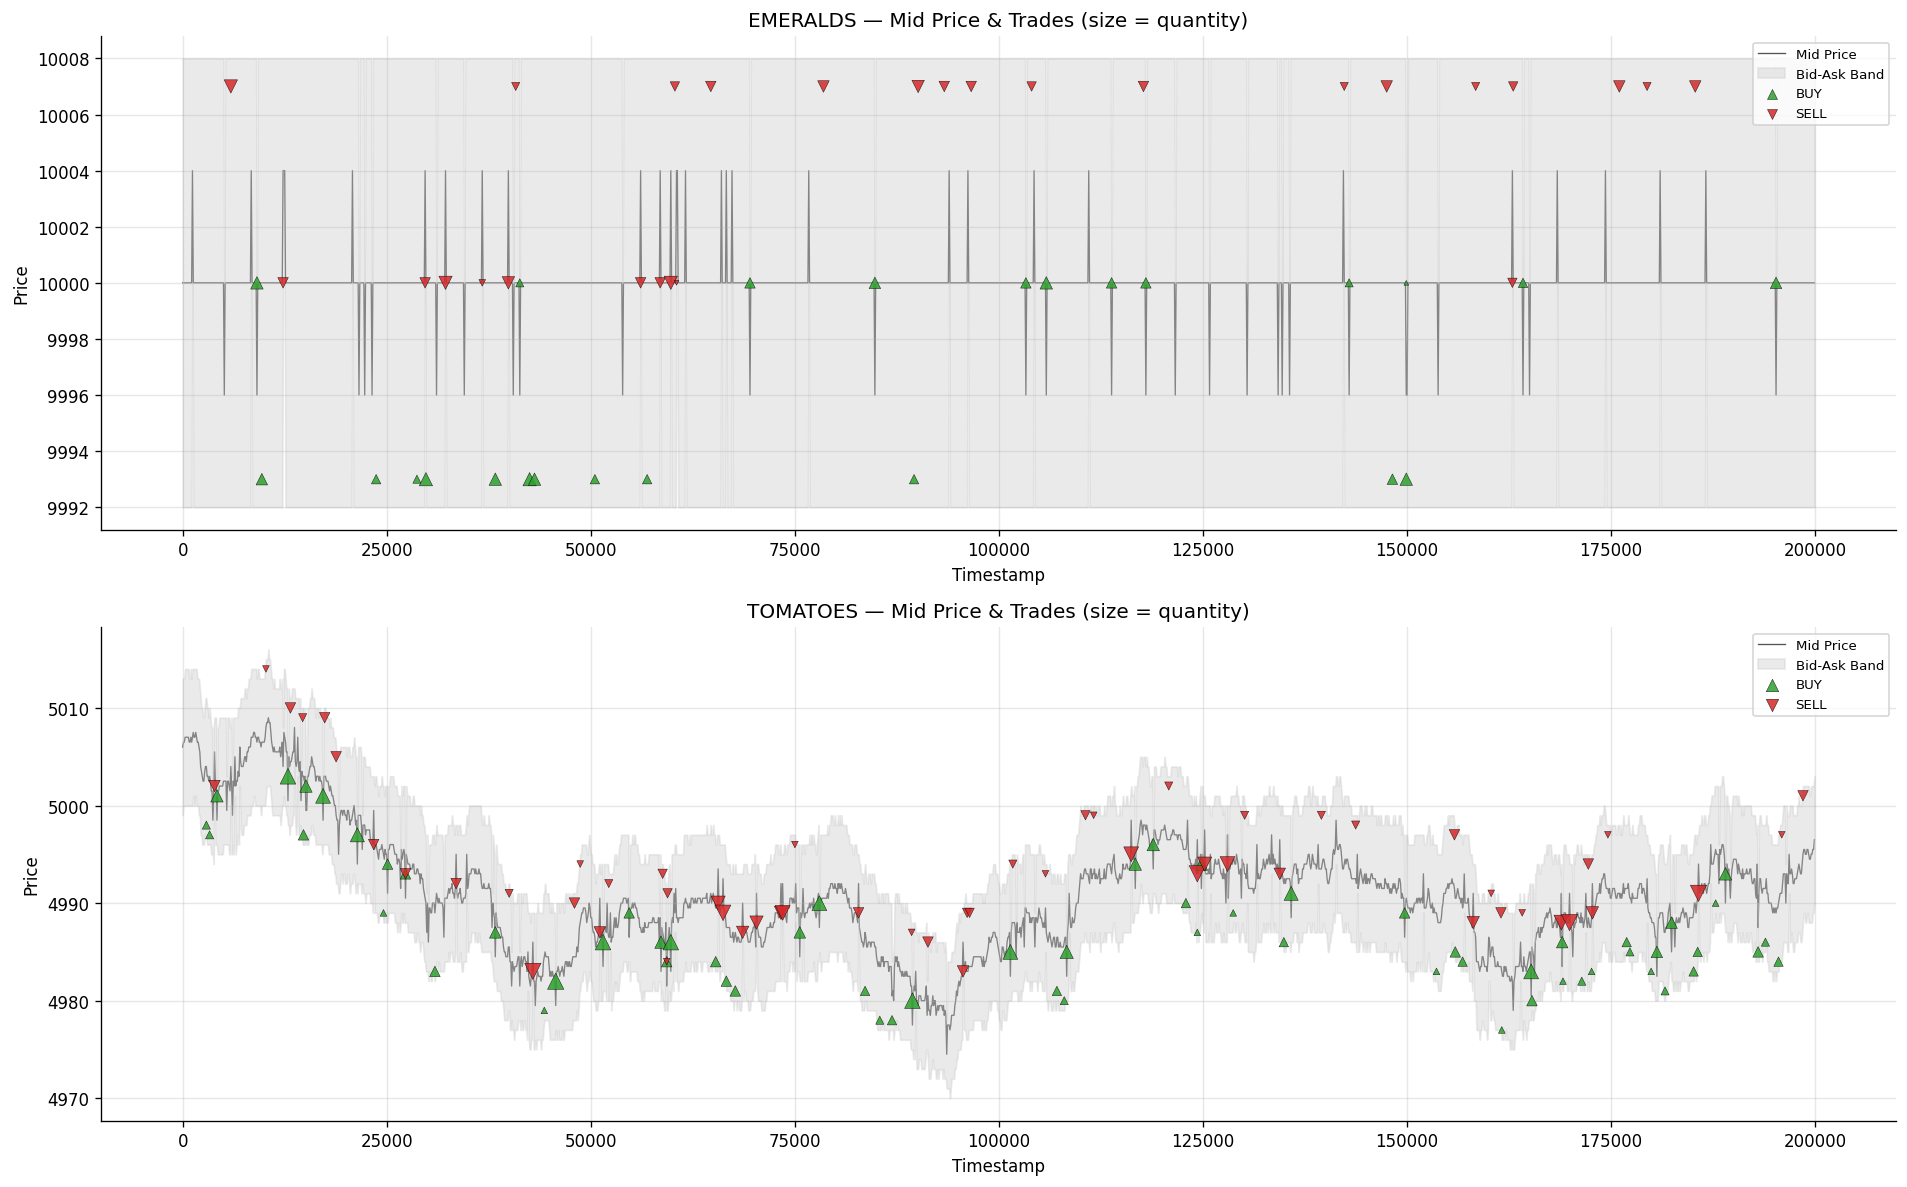

In [2]:
fig, axes = plt.subplots(len(products), 1, figsize=(16, 5 * len(products)), sharex=False)
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    act = activities[activities["product"] == product].sort_values("timestamp")
    tr = trades[trades["symbol"] == product]
    buys = tr[tr["side"] == "BUY"]
    sells = tr[tr["side"] == "SELL"]

    ax.plot(act["timestamp"], act["mid_price"], color="#555", lw=0.8, label="Mid Price", zorder=1)
    ax.fill_between(act["timestamp"], act["bid_price_1"], act["ask_price_1"],
                    color="#ccc", alpha=0.4, label="Bid-Ask Band")

    ax.scatter(buys["timestamp"], buys["price"], c="#2ca02c", s=buys["quantity"] * 8,
              marker="^", alpha=0.85, edgecolor="black", linewidth=0.3, label="BUY", zorder=3)
    ax.scatter(sells["timestamp"], sells["price"], c="#d62728", s=sells["quantity"] * 8,
              marker="v", alpha=0.85, edgecolor="black", linewidth=0.3, label="SELL", zorder=3)

    ax.set_title(f"{product} — Mid Price & Trades (size = quantity)", fontsize=12)
    ax.set_ylabel("Price")
    ax.set_xlabel("Timestamp")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

Total EMERALDS ticks: 2000
Ticks with spread < 16: 59 (2.9%)
Unique bid prices in tight: [np.int64(9992), np.int64(10000)]
Unique ask prices in tight: [np.int64(10000), np.int64(10008)]


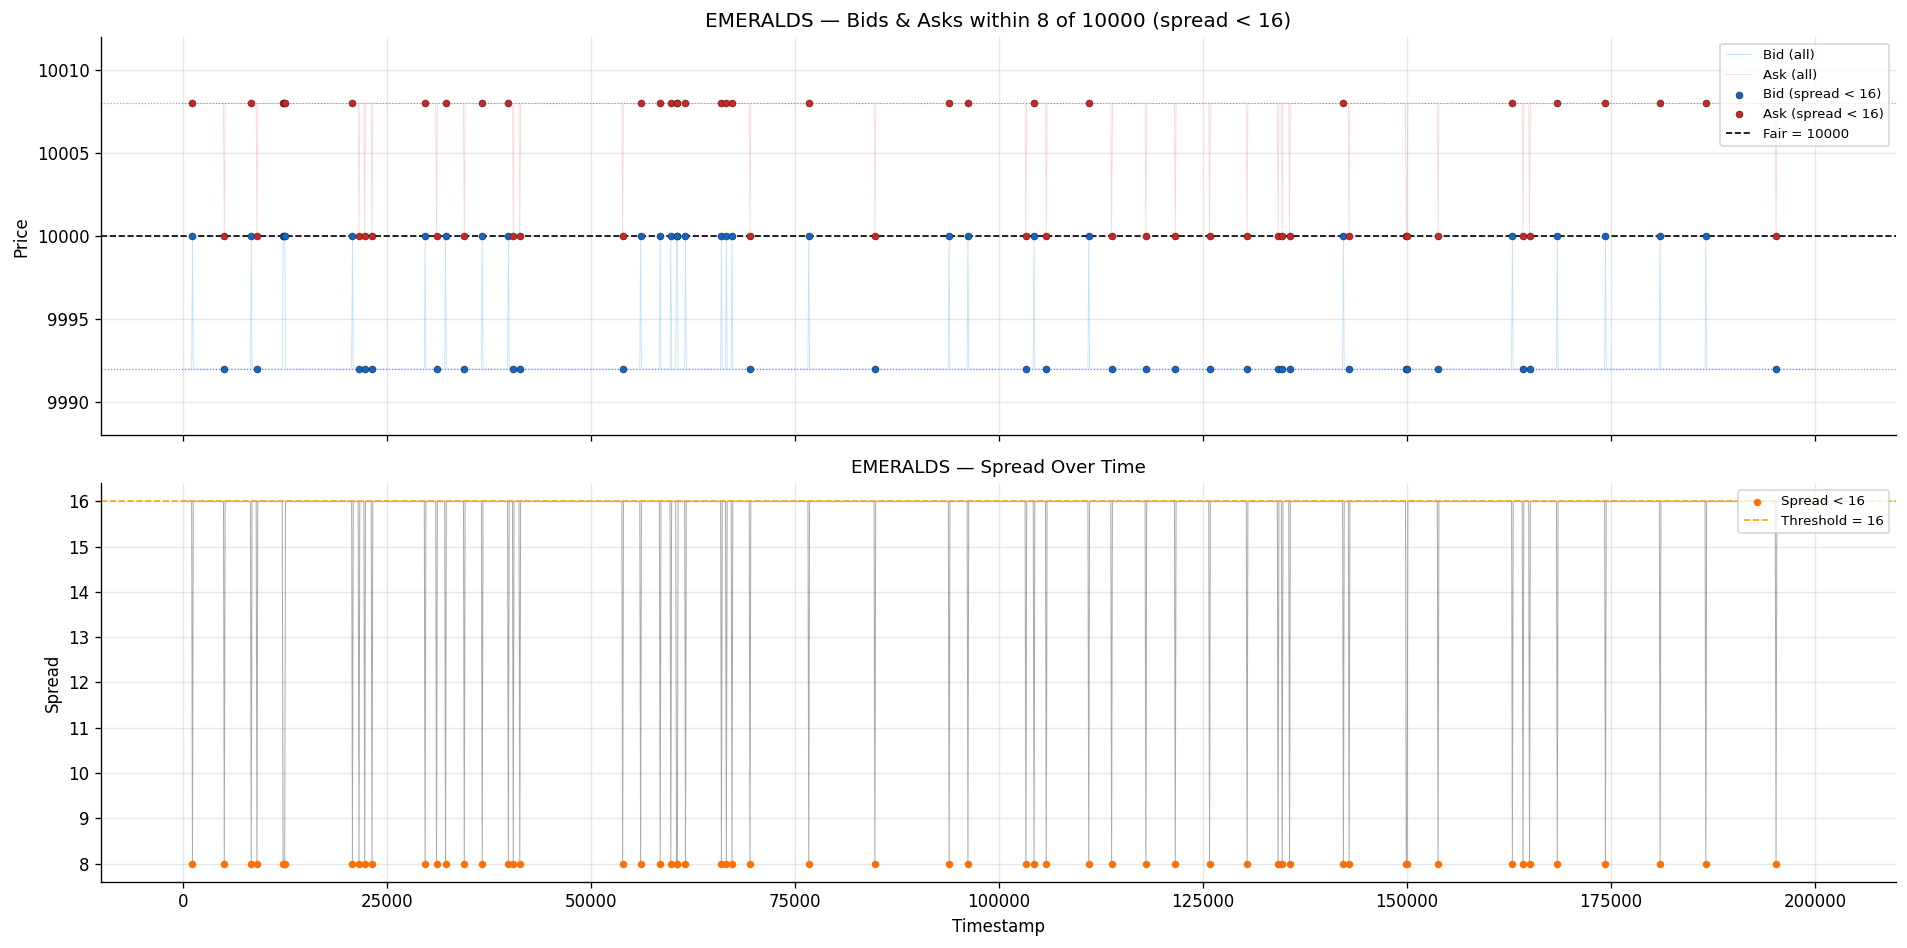

In [3]:
# Filter EMERALDS ticks where best bid or ask is within 8 of 10000
# i.e. bid >= 9993 or ask <= 10007 (tighter than the usual 9992/10008)
FAIR = 10000
THRESHOLD = 8

em = activities[activities["product"] == "EMERALDS"].sort_values("timestamp").copy()
em["bid_dist"] = FAIR - em["bid_price_1"]   # distance from fair to best bid
em["ask_dist"] = em["ask_price_1"] - FAIR   # distance from fair to best ask
em["spread"] = em["ask_price_1"] - em["bid_price_1"]

tight = em[em["spread"] < 2 * THRESHOLD].copy()  # spread < 16 means at least one side is closer than 8

print(f"Total EMERALDS ticks: {len(em)}")
print(f"Ticks with spread < {2 * THRESHOLD}: {len(tight)} ({len(tight)/len(em)*100:.1f}%)")
print(f"Unique bid prices in tight: {sorted(tight['bid_price_1'].unique())}")
print(f"Unique ask prices in tight: {sorted(tight['ask_price_1'].unique())}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: bid and ask prices over time, highlighting tight-spread ticks
ax1.plot(em["timestamp"], em["bid_price_1"], color="#64B5F6", lw=0.5, alpha=0.4, label="Bid (all)")
ax1.plot(em["timestamp"], em["ask_price_1"], color="#EF9A9A", lw=0.5, alpha=0.4, label="Ask (all)")

ax1.scatter(tight["timestamp"], tight["bid_price_1"], c="#1565C0", s=18, zorder=3,
            label=f"Bid (spread < {2*THRESHOLD})", marker="o", edgecolor="black", linewidth=0.2)
ax1.scatter(tight["timestamp"], tight["ask_price_1"], c="#C62828", s=18, zorder=3,
            label=f"Ask (spread < {2*THRESHOLD})", marker="o", edgecolor="black", linewidth=0.2)

ax1.axhline(FAIR, color="black", lw=1, ls="--", label="Fair = 10000")
ax1.axhline(FAIR - THRESHOLD, color="blue", lw=0.7, ls=":", alpha=0.5)
ax1.axhline(FAIR + THRESHOLD, color="red", lw=0.7, ls=":", alpha=0.5)
ax1.set_ylim(FAIR - 12, FAIR + 12)
ax1.set_ylabel("Price")
ax1.set_title(f"EMERALDS — Bids & Asks within {THRESHOLD} of {FAIR} (spread < {2*THRESHOLD})", fontsize=12)
ax1.legend(loc="upper right", fontsize=8)

# Bottom: spread over time
ax2.plot(em["timestamp"], em["spread"], color="#555", lw=0.6, alpha=0.5)
ax2.scatter(tight["timestamp"], tight["spread"], c="#FF6F00", s=12, zorder=3, label=f"Spread < {2*THRESHOLD}")
ax2.axhline(2 * THRESHOLD, color="orange", lw=1, ls="--", label=f"Threshold = {2*THRESHOLD}")
ax2.set_ylabel("Spread")
ax2.set_xlabel("Timestamp")
ax2.set_title("EMERALDS — Spread Over Time", fontsize=11)
ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 1.5 — EMERALDS Tight Spread Opportunities (spread < 8 from 10,000)

## 2 — PnL Over Time (per product)

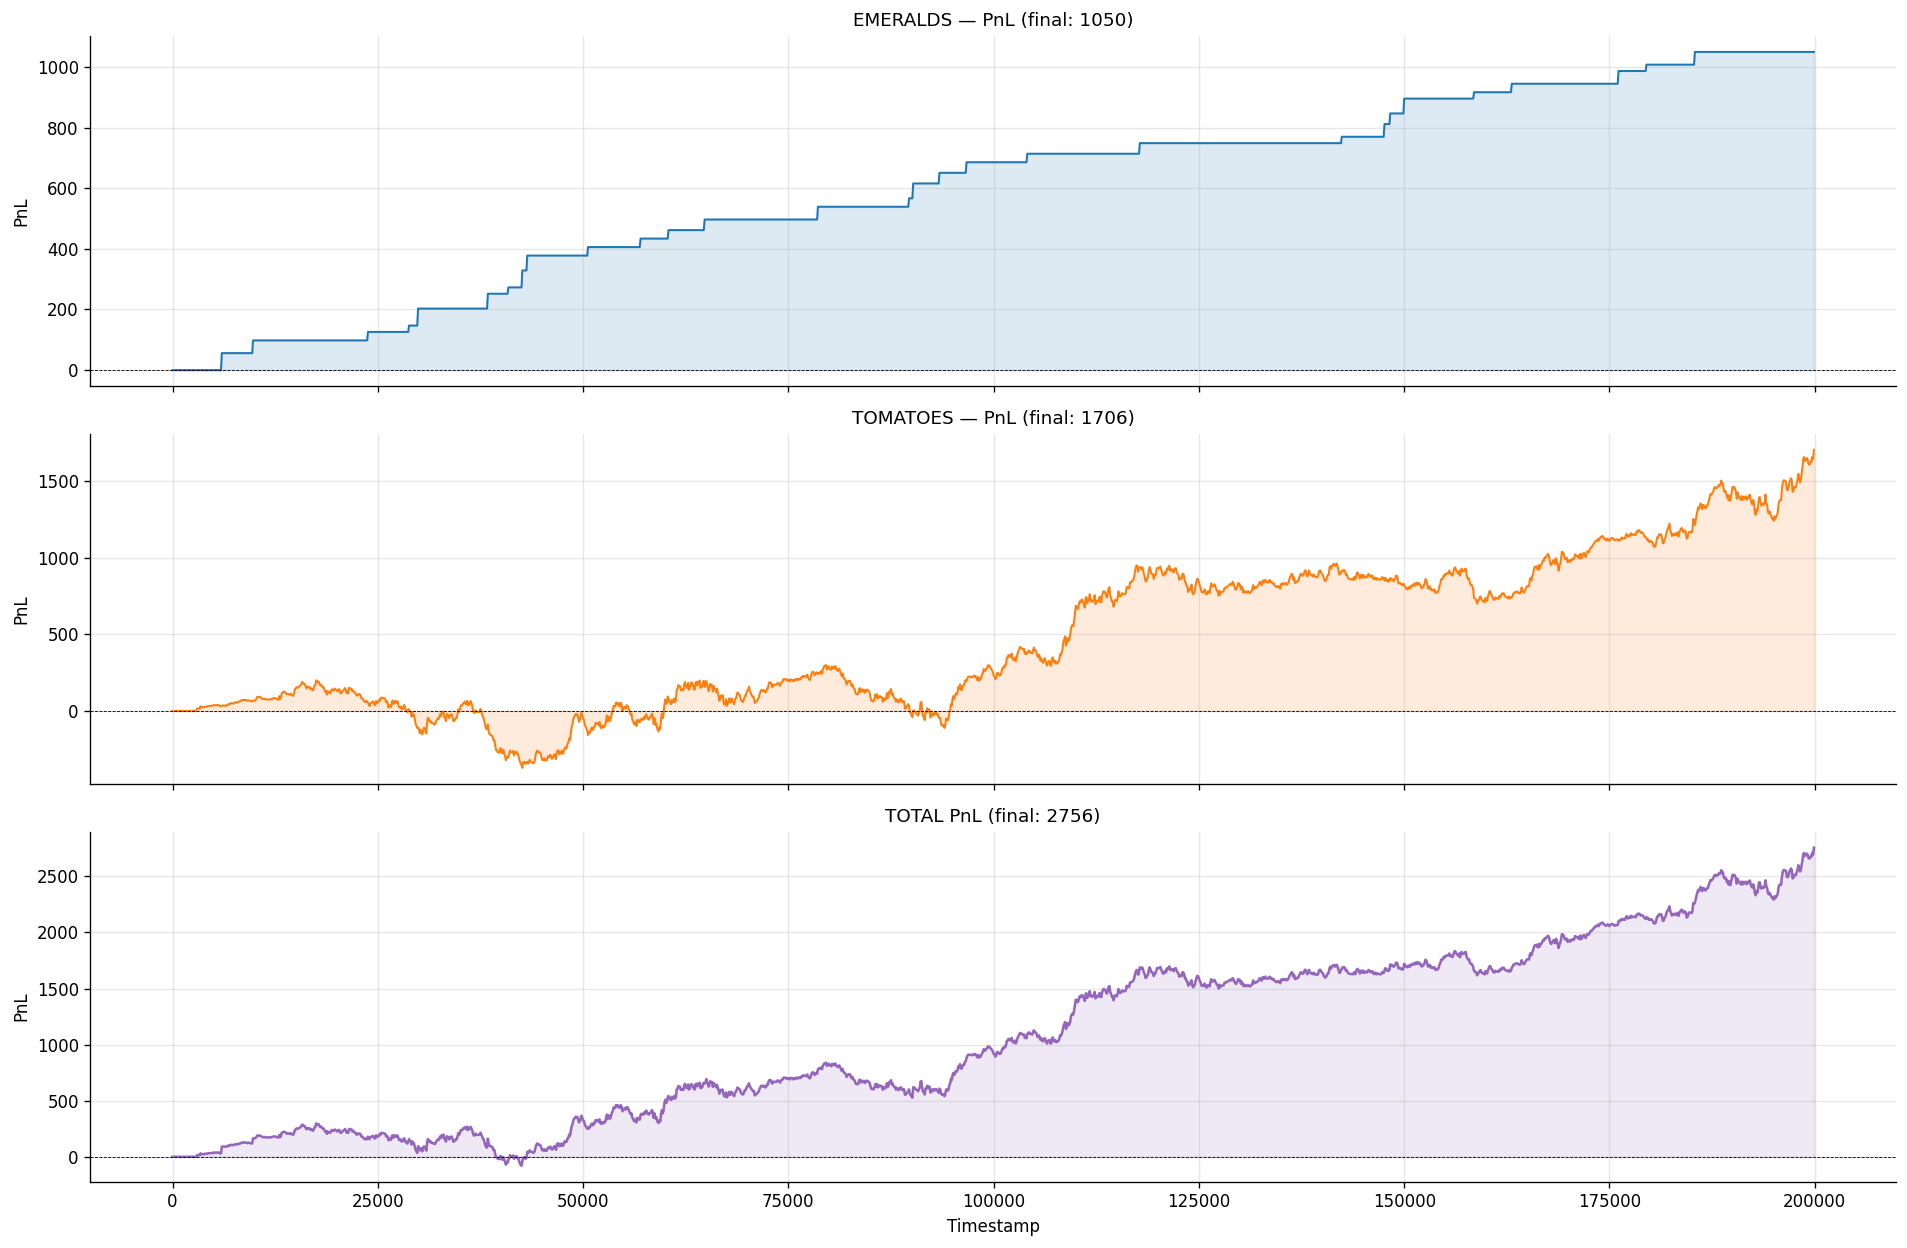

In [4]:
fig, axes = plt.subplots(len(products) + 1, 1, figsize=(16, 3.5 * (len(products) + 1)), sharex=True)

total_pnl = None
for ax, product in zip(axes, products):
    act = activities[activities["product"] == product].sort_values("timestamp")
    pnl = act["profit_and_loss"].values
    ts = act["timestamp"].values

    if total_pnl is None:
        total_pnl = pd.Series(pnl, index=ts)
    else:
        total_pnl = total_pnl.add(pd.Series(pnl, index=ts), fill_value=0)

    color = "#1f77b4" if product == "EMERALDS" else "#ff7f0e"
    ax.plot(ts, pnl, color=color, lw=1.2)
    ax.fill_between(ts, 0, pnl, alpha=0.15, color=color)
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{product} — PnL (final: {pnl[-1]:.0f})", fontsize=11)
    ax.set_ylabel("PnL")

# Total
ax_total = axes[-1]
ax_total.plot(total_pnl.index, total_pnl.values, color="#9467bd", lw=1.5)
ax_total.fill_between(total_pnl.index, 0, total_pnl.values, alpha=0.15, color="#9467bd")
ax_total.axhline(0, color="black", lw=0.5, ls="--")
ax_total.set_title(f"TOTAL PnL (final: {total_pnl.values[-1]:.0f})", fontsize=11)
ax_total.set_ylabel("PnL")
ax_total.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## 3 — Position Over Time

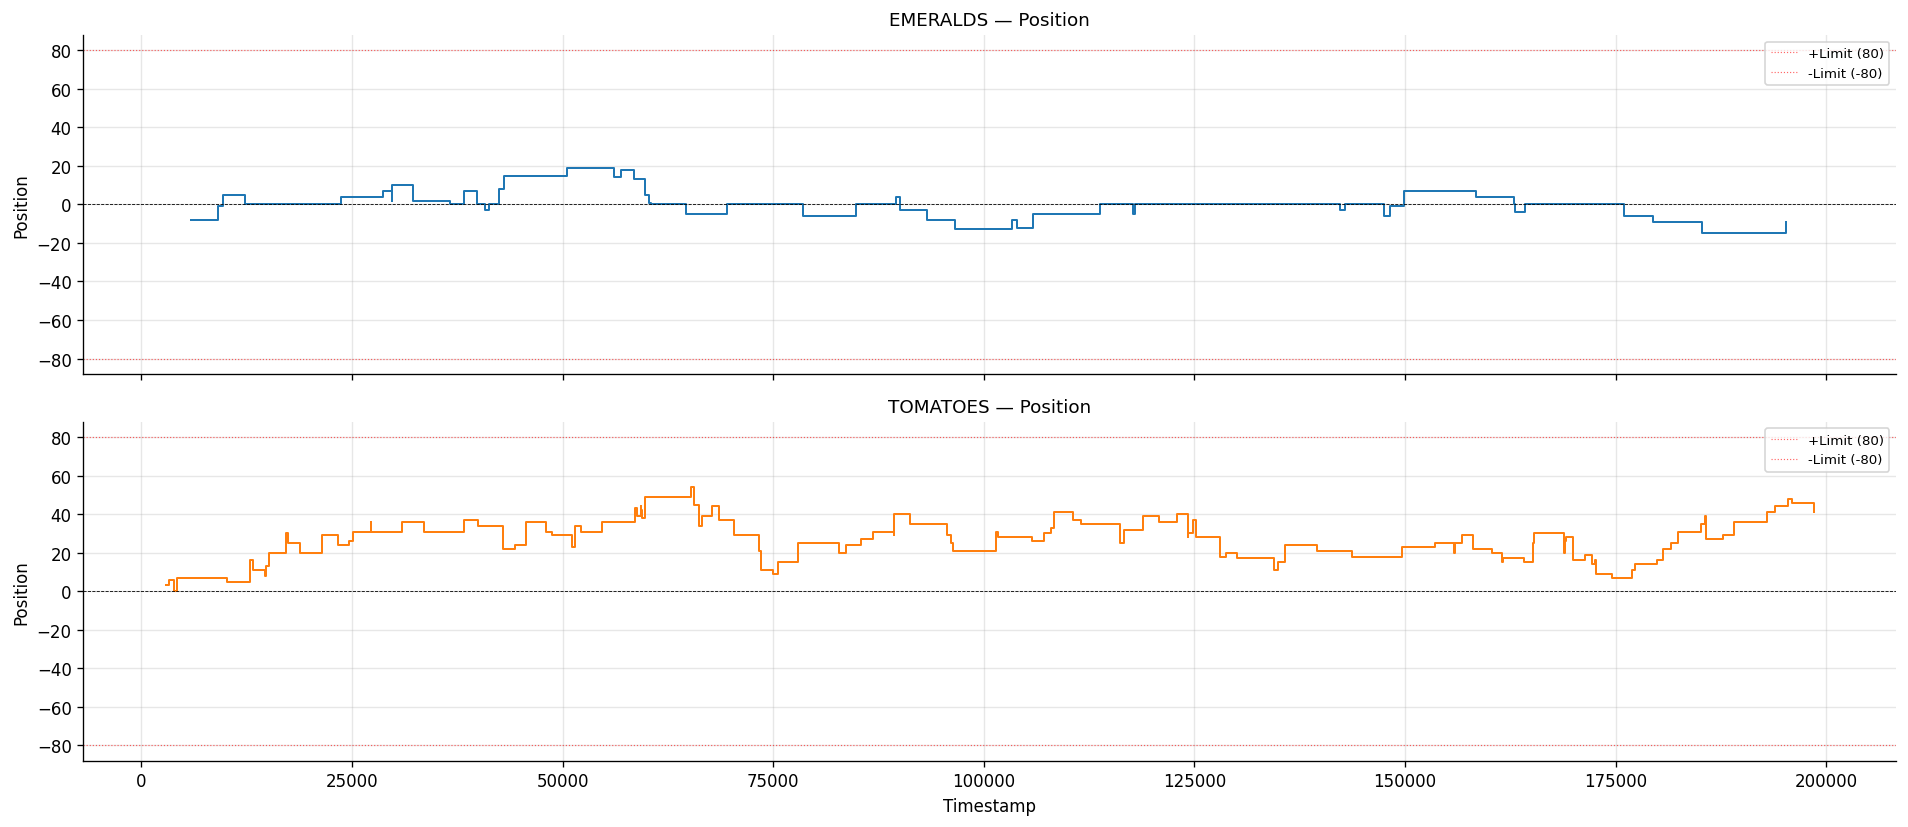

In [5]:
fig, axes = plt.subplots(len(products), 1, figsize=(16, 3.5 * len(products)), sharex=True)
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    tr = trades[trades["symbol"] == product].sort_values("timestamp")
    tr = tr.copy()
    tr["cumulative_position"] = tr["signed_qty"].cumsum()

    ax.step(tr["timestamp"], tr["cumulative_position"], where="post", lw=1.2,
            color="#1f77b4" if product == "EMERALDS" else "#ff7f0e")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.axhline(80, color="red", lw=0.7, ls=":", alpha=0.6, label="+Limit (80)")
    ax.axhline(-80, color="red", lw=0.7, ls=":", alpha=0.6, label="-Limit (-80)")
    ax.set_title(f"{product} — Position", fontsize=11)
    ax.set_ylabel("Position")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 4 — Trade Price vs Mid Price (Edge Captured)

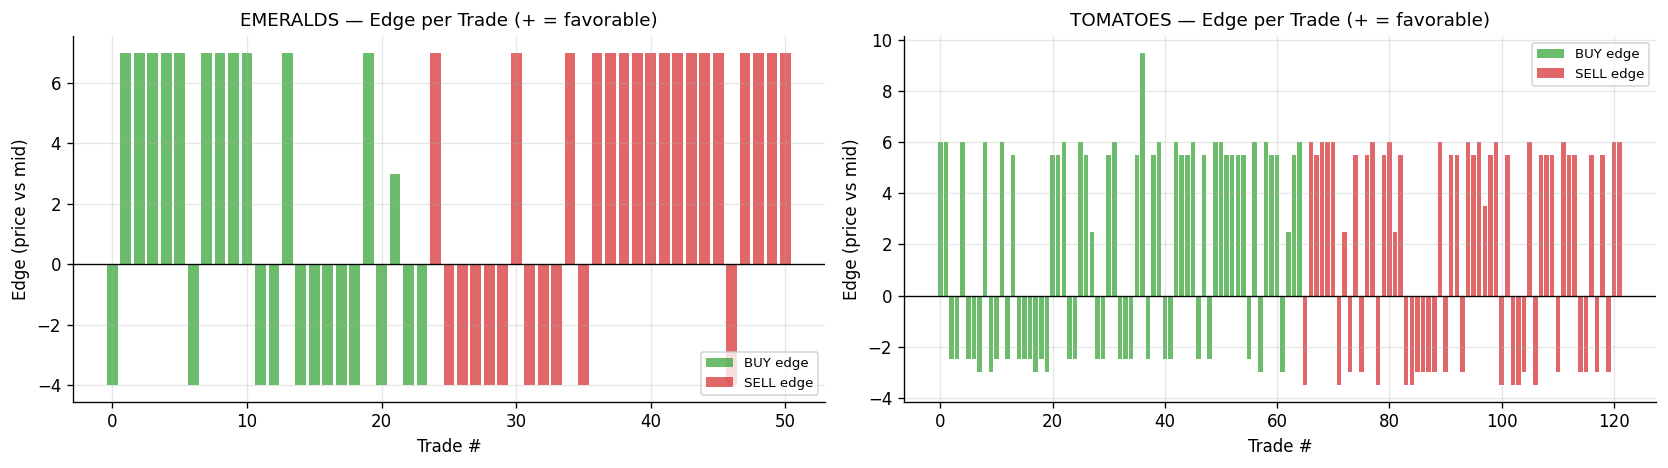

=== Edge Summary ===

EMERALDS:
  Trades: 51 (24 buys, 27 sells)
  Mean edge: 2.18
  Total edge*qty: 594
  Avg quantity: 5.0

TOMATOES:
  Trades: 122 (65 buys, 57 sells)
  Mean edge: 1.98
  Total edge*qty: 122
  Avg quantity: 5.4


In [6]:
# For each of our trades, compute the edge: how far from mid we traded
# Positive edge = good (bought below mid or sold above mid)

mid_lookup = activities.set_index(["timestamp", "product"])["mid_price"]

edges = []
for _, t in trades.iterrows():
    key = (t["timestamp"], t["symbol"])
    if key in mid_lookup.index:
        mid = mid_lookup.loc[key]
        if isinstance(mid, pd.Series):
            mid = mid.iloc[0]
        if t["side"] == "BUY":
            edge = mid - t["price"]  # positive = bought below mid
        else:
            edge = t["price"] - mid  # positive = sold above mid
        edges.append(edge)
    else:
        edges.append(np.nan)

trades["edge"] = edges
trades["edge_x_qty"] = trades["edge"] * trades["quantity"]

fig, axes = plt.subplots(1, len(products), figsize=(7 * len(products), 4))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    tr = trades[trades["symbol"] == product]
    buys = tr[tr["side"] == "BUY"]
    sells = tr[tr["side"] == "SELL"]

    ax.bar(range(len(buys)), buys["edge"].values, color="#2ca02c", alpha=0.7, label="BUY edge")
    ax.bar(range(len(buys), len(buys) + len(sells)), sells["edge"].values,
           color="#d62728", alpha=0.7, label="SELL edge")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{product} — Edge per Trade (+ = favorable)", fontsize=11)
    ax.set_ylabel("Edge (price vs mid)")
    ax.set_xlabel("Trade #")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary stats
print("=== Edge Summary ===")
for product in products:
    tr = trades[trades["symbol"] == product]
    print(f"\n{product}:")
    print(f"  Trades: {len(tr)} ({(tr['side']=='BUY').sum()} buys, {(tr['side']=='SELL').sum()} sells)")
    print(f"  Mean edge: {tr['edge'].mean():.2f}")
    print(f"  Total edge*qty: {tr['edge_x_qty'].sum():.0f}")
    print(f"  Avg quantity: {tr['quantity'].mean():.1f}")

## 5 — Trade Distribution (Price Histogram)

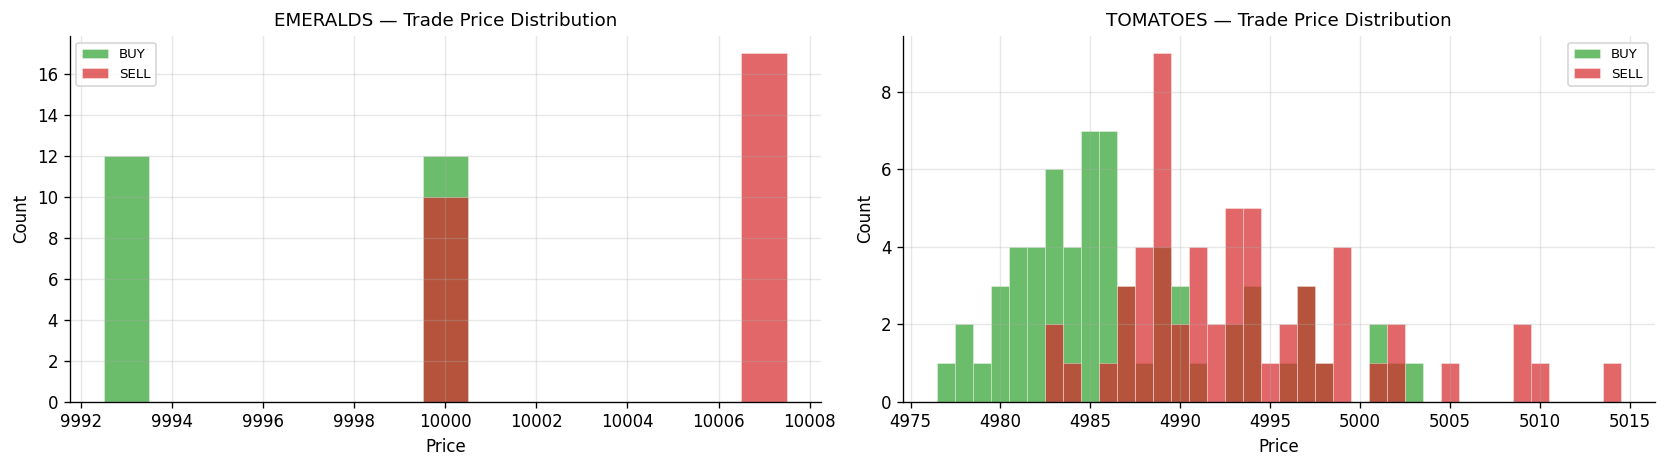

In [7]:
fig, axes = plt.subplots(1, len(products), figsize=(7 * len(products), 4))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    tr = trades[trades["symbol"] == product]
    buys = tr[tr["side"] == "BUY"]
    sells = tr[tr["side"] == "SELL"]

    all_prices = tr["price"].unique()
    bins = np.arange(all_prices.min() - 0.5, all_prices.max() + 1.5, 1)

    ax.hist(buys["price"], bins=bins, color="#2ca02c", alpha=0.7, label="BUY", edgecolor="white", lw=0.3)
    ax.hist(sells["price"], bins=bins, color="#d62728", alpha=0.7, label="SELL", edgecolor="white", lw=0.3)
    ax.set_title(f"{product} — Trade Price Distribution", fontsize=11)
    ax.set_xlabel("Price")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6 — Trade Timeline (Quantity Heatmap)

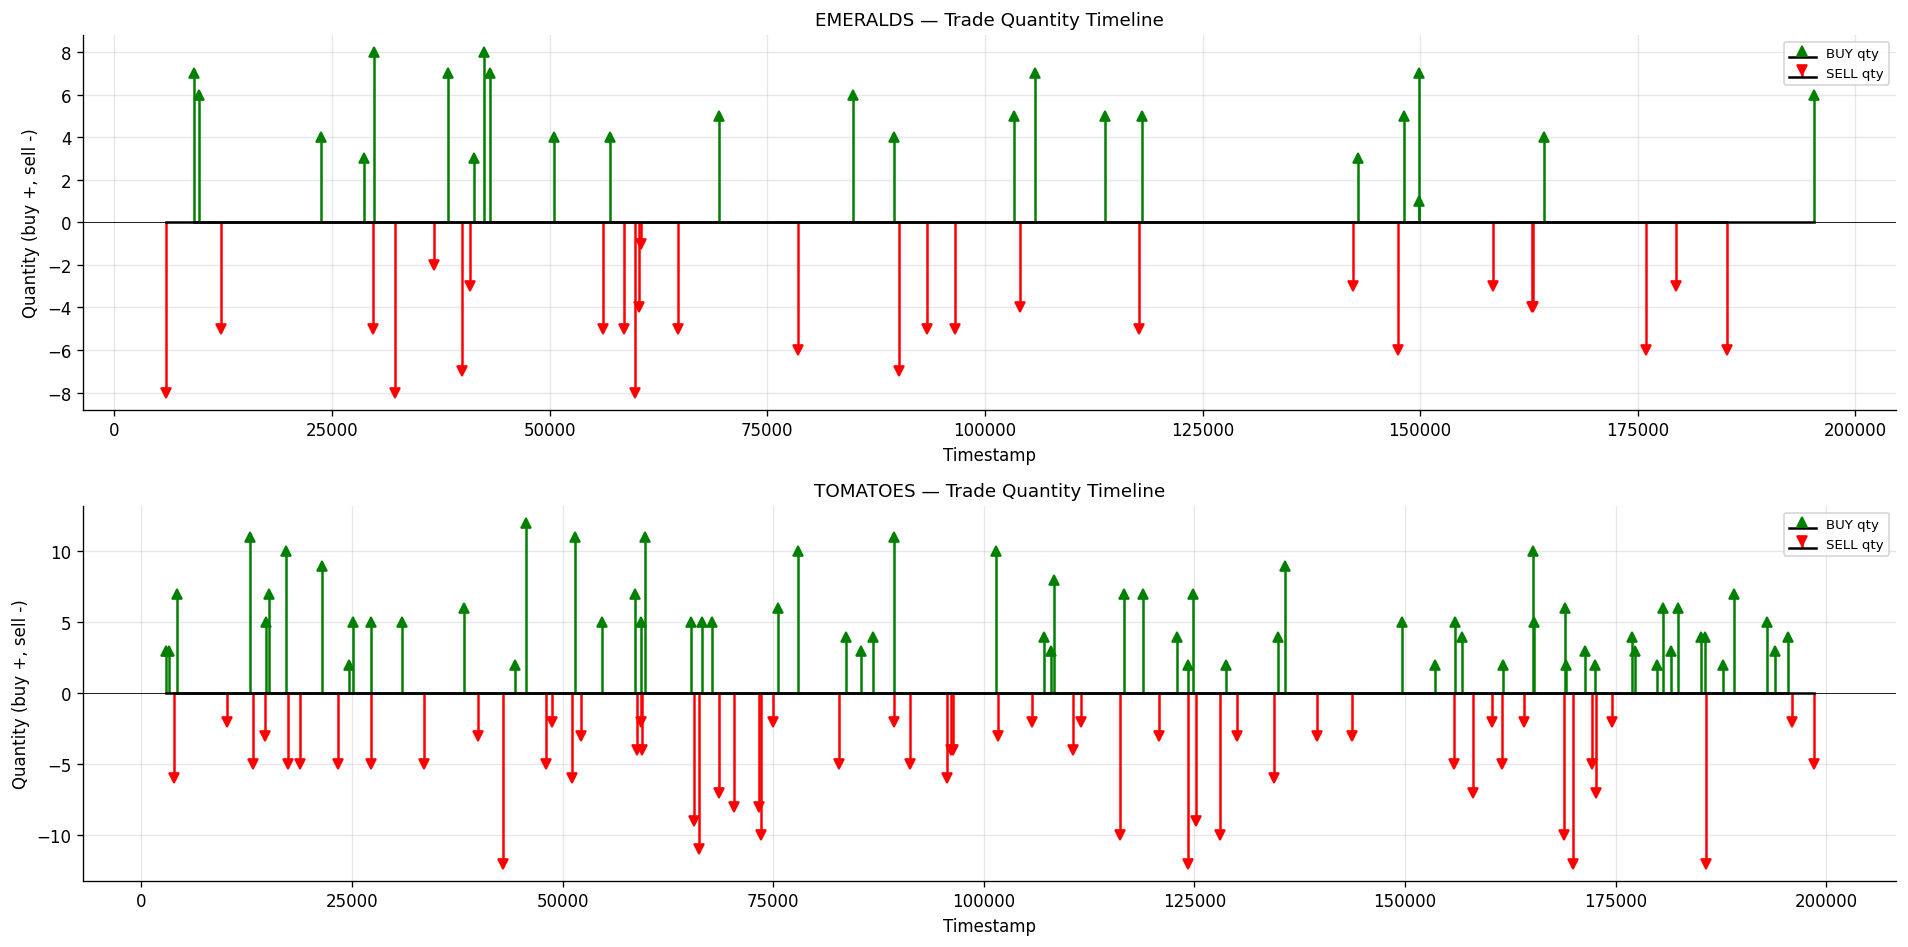

In [8]:
fig, axes = plt.subplots(len(products), 1, figsize=(16, 4 * len(products)), sharex=False)
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    tr = trades[trades["symbol"] == product].copy()
    buys = tr[tr["side"] == "BUY"]
    sells = tr[tr["side"] == "SELL"]

    ax.stem(buys["timestamp"], buys["quantity"], linefmt="g-", markerfmt="g^", basefmt="k-",
            label="BUY qty")
    ax.stem(sells["timestamp"], -sells["quantity"], linefmt="r-", markerfmt="rv", basefmt="k-",
            label="SELL qty")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{product} — Trade Quantity Timeline", fontsize=11)
    ax.set_ylabel("Quantity (buy +, sell -)")
    ax.set_xlabel("Timestamp")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7 — Summary Table

In [9]:
rows = []
for product in products:
    act = activities[activities["product"] == product].sort_values("timestamp")
    tr = trades[trades["symbol"] == product]
    buys = tr[tr["side"] == "BUY"]
    sells = tr[tr["side"] == "SELL"]
    final_pnl = act["profit_and_loss"].iloc[-1]

    rows.append({
        "Product": product,
        "Final PnL": final_pnl,
        "# Trades": len(tr),
        "# Buys": len(buys),
        "# Sells": len(sells),
        "Avg Buy Price": buys["price"].mean() if len(buys) > 0 else None,
        "Avg Sell Price": sells["price"].mean() if len(sells) > 0 else None,
        "Total Vol Bought": buys["quantity"].sum(),
        "Total Vol Sold": sells["quantity"].sum(),
        "Mean Edge": tr["edge"].mean(),
        "Total Edge*Qty": tr["edge_x_qty"].sum(),
    })

summary = pd.DataFrame(rows).set_index("Product")
pd.set_option("display.float_format", "{:.2f}".format)
summary

,Final PnL,# Trades,# Buys,# Sells,Avg Buy Price,Avg Sell Price,Total Vol Bought,Total Vol Sold,Mean Edge,Total Edge*Qty
Product,,,,,,,,,,
EMERALDS,1050.00,51,24,27,9996.50,10004.41,124,133,2.18,594.00
TOMATOES,1706.47,122,65,57,4987.09,4993.63,350,309,1.98,121.50
